In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import scipy.constants

from scipy.integrate import odeint
from scipy.optimize import minimize

In [2]:
import os
import sys
import inspect
currentdir = os.getcwd()
parentdir = os.path.dirname(currentdir)

#------------ FILES PARENTDIR ------------#
sys.path.insert(0, parentdir)
from NFW_class import NFW_profile, r1

# Rounding

In [3]:
"""
Usfeul function to formating the values of variables.
"""

def rounded_number(_number, _significant_digits):
    """
    Taking the value to rounded and and takes the amount of significant digits you specify.
    """
    return round(_number, _significant_digits - int(math.floor(math.log10(abs(_number)))) - 1)

# checking

number = 1234.23
significant_digits = 3

number_after_rounded = rounded_number(number, significant_digits)
print(number_after_rounded)

1230.0


# Constants

In [4]:
# setting constants value
const_h = 0.71025 # dimesionless
rho_c = 2.7754 * 10**2 * const_h**2 # [M_solar / kpc^3]

year = 365 * 24 * 60 * 60 # [s]
Gyr = 10**9 * year # [s]
kpc_SI = 3.08567758 * 10**19 # [m]
M_solar_SI = 1.98847 * 10**30 # [kg]
const_G = scipy.constants.G # [m^3 * kg^-1 * s^-2]
const_G_starUnits = const_G * kpc_SI**(-3) * M_solar_SI**(1) * Gyr**(2) # gravitational constant [kpc^3 Gyr^-2 Msun^-1]
print(const_G_starUnits)

# constants from paper 2206.12425
M_vir = 10**9.331 # [M_solar]
const_c = 15 # dimesionless
time_evolution = 0.1 * Gyr # [s]
sigma_m = 5 # [cm^2 / g]

# np.logspace(-1.0, 2.3, 70)

sigma_m_SI = sigma_m * 10**(-4) * 10**3 # [m^2 / kg]

4.492481999722144e-06


# Creating NFW Class

In [5]:
NFW_profile = NFW_profile(M_vir, const_c)

In [6]:
r_s = NFW_profile.r_s
rounded_r_s = rounded_number(r_s, 3)

rho_s = NFW_profile.rho_s
rounded_rho_s = rounded_number(rho_s, 3)

print(f"rho_s = {rounded_rho_s} [M_solar / kpc^3], r_s = {rounded_r_s} [kpc]")

rho_s = 17200000.0 [M_solar / kpc^3], r_s = 1.76 [kpc]


In [7]:
# new way to get r1
r_1 = r1(NFW_profile,sigmamx=sigma_m,tage=(time_evolution/Gyr))
print(f"r_1 = {r_1} [kpc]")

r_1 = 0.06890073082651252 [kpc]


# NFW density profile

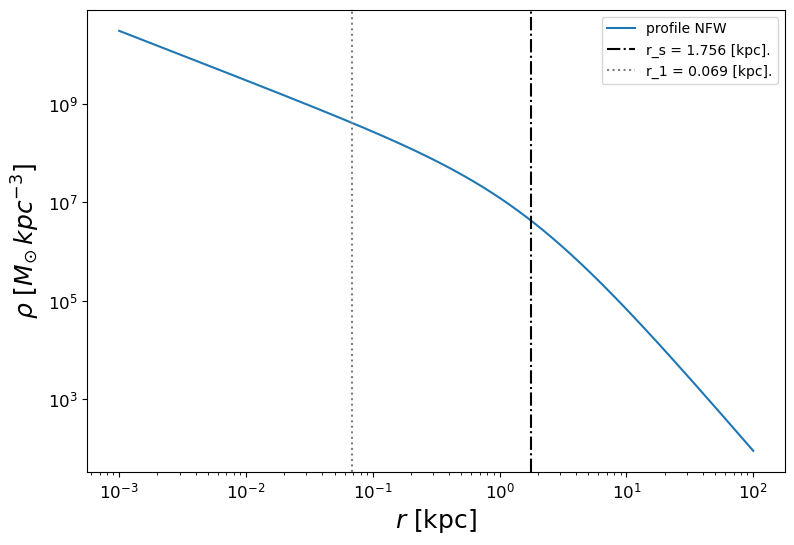

In [8]:
# Data to show
plot_r = np.logspace(-3.0, 2.0, num=300)
# NFW profile
plot_rho_NFW = NFW_profile.rho(plot_r)

# lines
r_s = NFW_profile.r_s
r_1 = r1(NFW_profile,sigmamx=sigma_m,tage=(time_evolution/Gyr))

# Plotting
fig, ax = plt.subplots(figsize=(9.0, 6.0))
ax.plot(plot_r, plot_rho_NFW, label="profile NFW")
# lines
plt.axvline(x=r_s, color='black', linestyle = 'dashdot',
                    label=f'r_s = {"{:.3f}".format(r_s)} [kpc].')
plt.axvline(x=r_1, color='grey', linestyle = 'dotted',
                    label=f'r_1 = {"{:.3f}".format(r_1)} [kpc].')
# log scale
ax.set_xscale('log')
ax.set_yscale('log')
# describe NFW profile
plt.ylabel(r"$\rho \, \, [M_{\odot} \, kpc^{-3}]$", fontsize=18)
plt.xlabel(r"$r$ [kpc]", fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend()
plt.show()

# NFW circular velocity

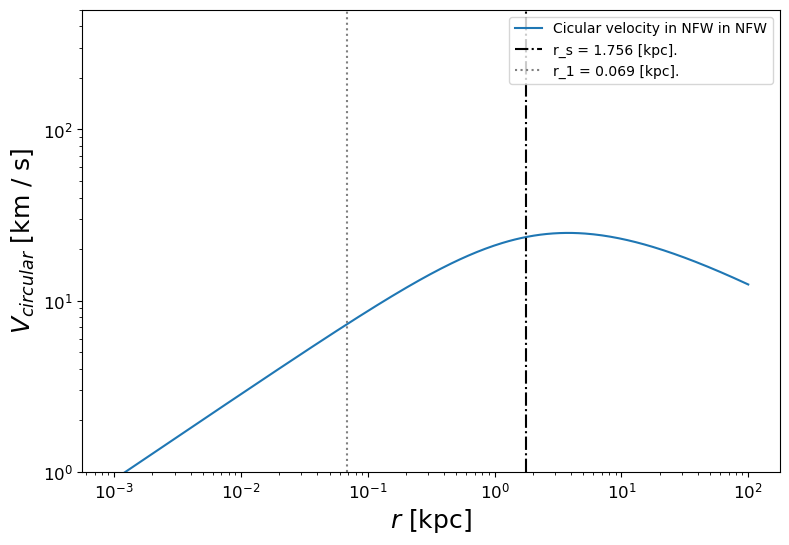

In [9]:
# Data to show
plot_r = np.logspace(-3.0, 2.0, num=300)
# NFW profile: circular velocity
Vcirc_NFW = NFW_profile.Vcirc(plot_r) #[kpc/Gyr]

Vcirc_NFW_SI = []
for i in range(0, len(plot_r)):
    Vcirc_SI = Vcirc_NFW[i] * kpc_SI / Gyr # [m/s]
    # append
    Vcirc_NFW_SI.append(Vcirc_SI * 10**(-3)) # [km / s]
    
# lines
r_s = NFW_profile.r_s

# Plotting
fig, ax = plt.subplots(figsize=(9.0, 6.0))
ax.plot(plot_r, Vcirc_NFW_SI, label="Cicular velocity in NFW in NFW")
# lines
plt.axvline(x=r_s, color='black', linestyle = 'dashdot',
                    label=f'r_s = {"{:.3f}".format(r_s)} [kpc].')
plt.axvline(x=r_1, color='grey', linestyle = 'dotted',
                    label=f'r_1 = {"{:.3f}".format(r_1)} [kpc].')
# log scale
ax.set_xscale('log')
ax.set_yscale('log')
# describe NFW profile
plt.ylim(10**0, 5*10**2)
plt.ylabel(r"$V_{circular}$ [km / s]", fontsize=18)
plt.xlabel(r"$r$ [kpc]", fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend()
plt.show()

# NFW averaged velocity using V_circular

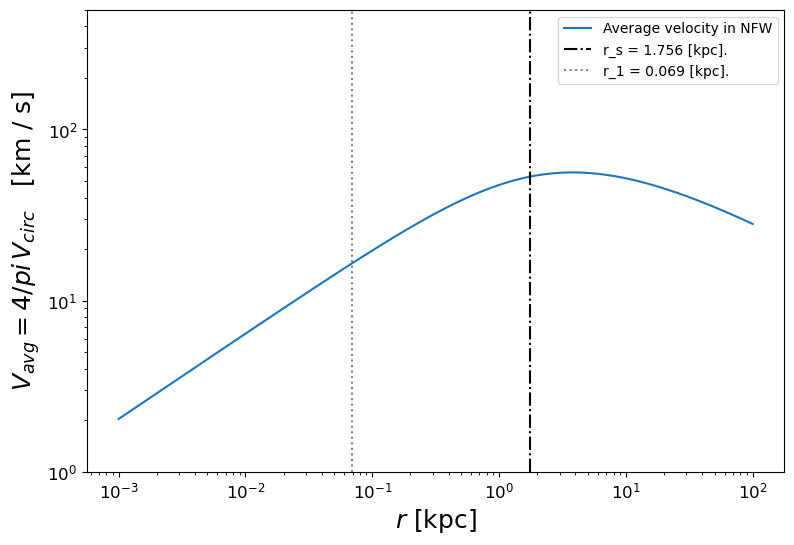

In [10]:
# Data to show
plot_r = np.logspace(-3.0, 2.0, num=300)
# NFW profile
Vcirc_NFW = NFW_profile.Vcirc(plot_r) #[kpc/Gyr]

Vavg_NFW_SI = []
for i in range(0, len(plot_r)):
    Vcirc_SI = Vcirc_NFW[i] * kpc_SI / Gyr # [m/s]
    Vavg_SI = Vcirc_SI * 4 / np.sqrt(np.pi) # [m/s]
    # append
    Vavg_NFW_SI.append(Vavg_SI * 10**(-3)) # [km / s]
    
# lines
r_s = NFW_profile.r_s

# Plotting
fig, ax = plt.subplots(figsize=(9.0, 6.0))
ax.plot(plot_r, Vavg_NFW_SI, label="Average velocity in NFW")
# lines
plt.axvline(x=r_s, color='black', linestyle = 'dashdot',
                    label=f'r_s = {"{:.3f}".format(r_s)} [kpc].')
plt.axvline(x=r_1, color='grey', linestyle = 'dotted',
                    label=f'r_1 = {"{:.3f}".format(r_1)} [kpc].')
# log scale
ax.set_xscale('log')
ax.set_yscale('log')
# describe NFW profile
plt.ylim(10**0, 5*10**2)
plt.ylabel(r"$V_{avg} = 4 /pi \, V_{circ} $   [km / s]", fontsize=18)
plt.xlabel(r"$r$ [kpc]", fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend()
plt.show()

# NFW profile dispersion velocity

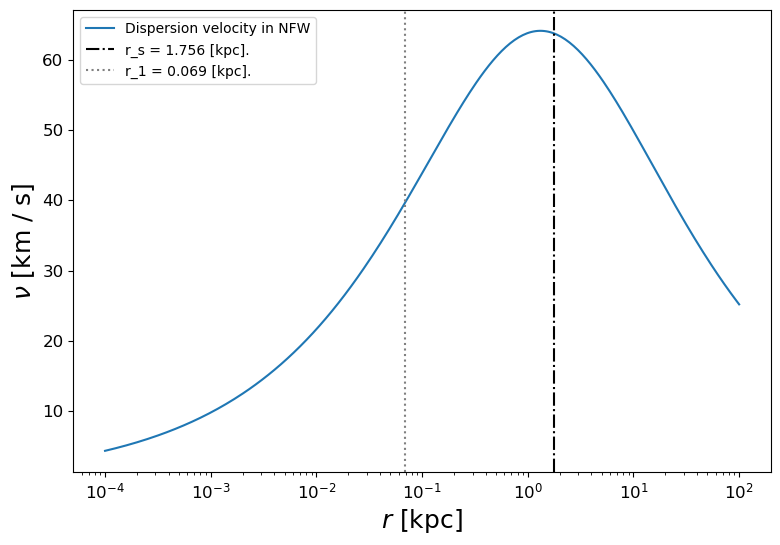

In [11]:
# Data to show
plot_r = np.logspace(-4.0, 2.0, num=300)
# NFW profile: dispersion velosity
NFW_profile.Vmax = NFW_profile.Vmax * 62/16
Vdis_NFW = NFW_profile.sigma(plot_r) #[kpc/Gyr]

Vdis_NFW_km_s = []
for i in range(0, len(plot_r)):
    Vdis_SI = Vdis_NFW[i] * kpc_SI / Gyr # [m/s]
    # append
    Vdis_NFW_km_s.append(Vdis_SI * 10**(-3)) # [km / s]
    
# lines
r_s = NFW_profile.r_s

# Plotting
fig, ax = plt.subplots(figsize=(9.0, 6.0))
ax.plot(plot_r, Vdis_NFW_km_s, label="Dispersion velocity in NFW")
# lines
plt.axvline(x=r_s, color='black', linestyle = 'dashdot',
                    label=f'r_s = {"{:.3f}".format(r_s)} [kpc].')
plt.axvline(x=r_1, color='grey', linestyle = 'dotted',
                    label=f'r_1 = {"{:.3f}".format(r_1)} [kpc].')
# log scale
ax.set_xscale('log')
# ax.set_yscale('log')
# describe NFW profile
# plt.ylim(10**0, 5*10**2)
plt.ylabel(r"$\nu$ [km / s]", fontsize=18)
plt.xlabel(r"$r$ [kpc]", fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend()
plt.show()